# 실습 4-2 : Under/Over Sampling

#### **<실습 내용>**

1. 클래스 불균형 데이터 확인
- t-SNE를 통한 시각화

2. Resampling 기법 적용
- Random Undersampling
- TomekLinks (Undersampling)
- SMOTE (Oversampling)
- SMOTE + TomekLinks (복합 Resampling)
- ADASYN (Oversampling)

3. Resampling 전후 T-SNE 및 성능 비교

## 분석 준비

### 주요 라이브러리 호출

In [35]:
# 실행해서 설치해주세요.
! pip install imbalanced-learn

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, f_classif

from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.combine import SMOTETomek

import warnings

### 데이터 불러오기

In [37]:
df = pd.read_csv("dataset/day4-2_data.csv")

# 결측 비율 50% 이상인 변수는 제거하고, 나머지는 중앙값으로 간단히 대치
missing_ratio = df.isnull().mean()
df = df.drop(columns=missing_ratio[missing_ratio >= 0.5].index)
df = df.drop(columns=["Time"]).fillna(df.median(numeric_only=True))

print("데이터 크기:", df.shape)
print("결측치 수:", df.isnull().sum().sum())
df.head()

데이터 크기: (1567, 563)
결측치 수: 0


,0,1,2,3,4,5,6,7,8,9,...,577,582,583,584,585,586,587,588,589,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


---

## 1) 클래스 불균형 확인

> **클래스 불균형(Class Imbalance)** 이란 정상 데이터의 양이 불량 데이터보다 훨씬 많은 상황을 의미함
> - 해결 기법: **Resampling** (Under/Over Sampling) 또는 **One-Class Learning Model**

In [38]:
X = df.drop(["Pass/Fail"], axis=1)  # 타겟 컬럼 제외한 나머지를 입력 변수로 사용
Y = df["Pass/Fail"]  # 타겟 컬럼

In [39]:
print("클래스 분포:")
print(Y.value_counts())  # 클래스별 개수 확인

클래스 분포:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


In [40]:
print("클래스 비율:")
print(np.round(Y.value_counts(normalize=True), 3))  # 클래스별 비율 확인 (소수점 3자리)

클래스 비율:
Pass/Fail
-1    0.934
 1    0.066
Name: proportion, dtype: float64


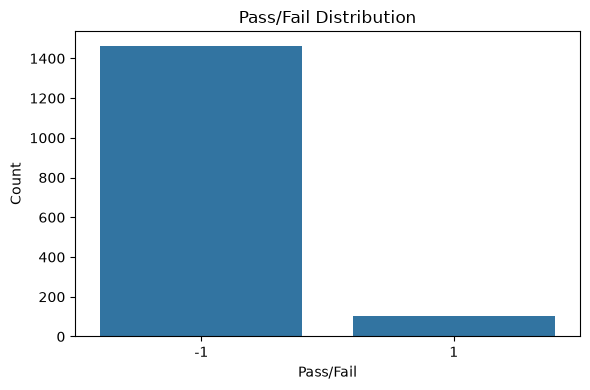

In [41]:
# 클래스 분포 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=Y.value_counts().index, y=Y.value_counts().values)  # 클래스별 개수를 막대그래프로 표시
plt.title("Pass/Fail Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 1-1) t-SNE를 통한 시각화

> **t-SNE**는 고차원 데이터를 2차원으로 매핑하여 시각화하는 기법임
> - 클래스 간 분리 정도를 시각적으로 확인할 수 있음
> - 분리가 잘 될수록 분류 모델이 두 클래스를 구분하기 쉬운 데이터라는 뜻임

In [42]:
# n_components=2 : 원래 수백 개 특성을 가진 데이터를 2차원 좌표(x, y)로 압축
# fit_transform(X) : X를 학습하면서 동시에 2차원 좌표로 변환

X_embedded = TSNE(n_components=2, random_state=0).fit_transform(X)
X_embedded

array([[-29.923544  , -10.609208  ],
       [  1.805597  , -24.816904  ],
       [ -0.28763786, -26.444748  ],
       ...,
       [ -2.927347  ,  -6.5208936 ],
       [-17.153276  ,  -6.7497854 ],
       [-19.1555    , -30.688726  ]], shape=(1567, 2), dtype=float32)

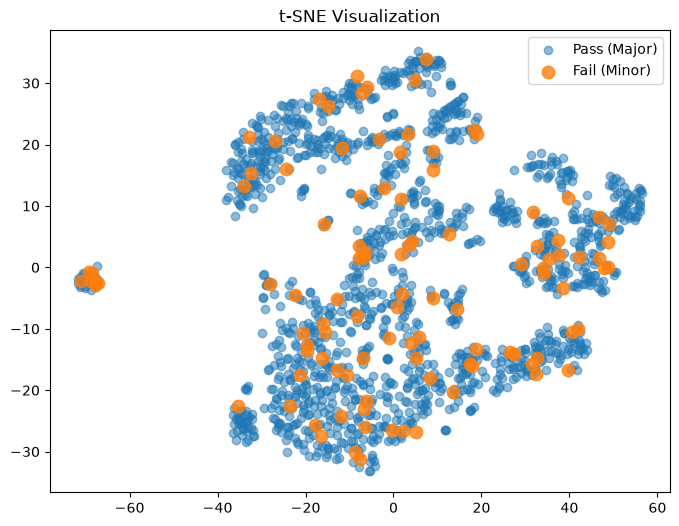

In [43]:
plt.figure(figsize=(8, 6))
# X_embedded[Y == -1, 0] : Pass 클래스(Y=-1)의 x좌표, X_embedded[Y == -1, 1] : y좌표
plt.scatter(X_embedded[Y == -1, 0], X_embedded[Y == -1, 1], label='Pass (Major)', alpha=0.5)  # 다수 클래스(Pass) 산점도
# X_embedded[Y == 1, 0] : Fail 클래스(Y=1)의 x좌표, X_embedded[Y == 1, 1] : y좌표
plt.scatter(X_embedded[Y == 1, 0], X_embedded[Y == 1, 1], label='Fail (Minor)', alpha=0.8, s=80)  # 소수 클래스(Fail) 산점도, 점 크기 크게
plt.legend()
plt.title("t-SNE Visualization")
plt.show()

---

## 2) Resampling 기법 적용

| 기법 | 유형 | 설명 |
|---|---|---|
| TomekLinks | Undersampling | 서로 다른 클래스끼리 너무 가까이 붙어있는 다수 클래스 샘플을 제거함 |
| SMOTE | Oversampling | 소수 클래스 샘플들 사이를 보간해서 새로운 가상 샘플을 만들어냄 |
| SMOTE + TomekLinks | 복합 Resampling | SMOTE로 소수 클래스를 늘린 뒤, TomekLinks로 애매하게 겹치는 샘플을 정리함 |
| ADASYN | Oversampling | SMOTE와 비슷하지만 구분이 어려운 샘플 주변에 더 많은 가상 샘플을 만들어냄 |

> Resampling은 **학습 데이터에만** 적용하고, 테스트 데이터는 원본 그대로 유지해야 함

In [44]:
# test는 실제 환경과 동일한 불균형 상태를 유지해야 모델 성능을 제대로 평가할 수 있음

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
print("학습 데이터 클래스 분포:")
print(Y_train.value_counts())

학습 데이터 클래스 분포:
Pass/Fail
-1    1170
 1      83
Name: count, dtype: int64


### Feature Selection

Fail 샘플(약 83개) 대비 feature가 500개 이상이라 노이즈 변수가 많습니다.  
**학습 데이터 기준**으로 Fail과 통계적으로 연관 높은 상위 `k`개 변수만 남기고, 테스트는 `transform`만 적용합니다.

In [45]:
K_BEST = 30  # Fail 샘플 수 대비 적절한 feature 수 (20~50 사이에서 조정 가능)
Y_train_bin = Y_train.map({-1: 0, 1: 1})

selector = SelectKBest(score_func=f_classif, k=K_BEST)
X_train = selector.fit_transform(X_train, Y_train_bin)  # 학습 데이터로 feature 선택
X_test = selector.transform(X_test)  # 테스트는 동일 기준으로 변환만

print(f"선택된 feature 수: {X_train.shape[1]}")

선택된 feature 수: 30


### 2-1) TomekLinks (Undersampling)

> **Tomek Links**는 서로 다른 클래스끼리 너무 가까이 붙어있는 다수 클래스 샘플을 제거함

In [46]:
X_TomekLinks, Y_TomekLinks = TomekLinks().fit_resample(X_train, Y_train)  # TomekLinks로 다수 클래스 일부 제거 (undersampling)

# 적용 전/후 클래스별 개수 비교
compare_TL = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_TomekLinks.value_counts()})
compare_TL["변화"] = compare_TL["적용 후"] - compare_TL["적용 전"]  # 클래스별 변화량 계산
compare_TL

,적용 전,적용 후,변화
Pass/Fail,,,
-1,1170,1129,-41
1,83,83,0


### 2-2) SMOTE (Oversampling)

> **SMOTE**는 소수 클래스 샘플들 사이를 보간해서 새로운 가상 샘플을 만들어냄

In [47]:
X_SMOTE, Y_SMOTE = SMOTE(random_state=10).fit_resample(X_train, Y_train)  # SMOTE로 소수 클래스를 다수 클래스 수만큼 늘림 (oversampling)

# 적용 전/후 클래스별 개수 비교
compare_SMOTE = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_SMOTE.value_counts()})
compare_SMOTE["변화"] = compare_SMOTE["적용 후"] - compare_SMOTE["적용 전"]  # 클래스별 변화량 계산
compare_SMOTE

,적용 전,적용 후,변화
Pass/Fail,,,
-1,1170,1170,0
1,83,1170,1087


### 2-3) SMOTE + TomekLinks (복합 Resampling)

> SMOTE로 소수 클래스를 늘린 뒤, TomekLinks로 애매하게 겹치는 샘플을 정리함

In [48]:
X_SMOTETomek, Y_SMOTETomek = SMOTETomek(random_state=10).fit_resample(X_train, Y_train)  # SMOTE로 늘린 뒤 TomekLinks로 겹치는 샘플 정리 (복합 resampling)

# 적용 전/후 클래스별 개수 비교
compare_SMOTE_TL = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_SMOTETomek.value_counts()})
compare_SMOTE_TL["변화"] = compare_SMOTE_TL["적용 후"] - compare_SMOTE_TL["적용 전"]  # 클래스별 변화량 계산
compare_SMOTE_TL

,적용 전,적용 후,변화
Pass/Fail,,,
-1,1170,1156,-14
1,83,1156,1073


### 2-4) ADASYN (Oversampling)

> **ADASYN**은 SMOTE를 개선한 기법으로, 다수 클래스와 인접한 소수 클래스 샘플 주변에 더 많은 데이터를 생성함
> - 즉 분류가 어려운 경계 영역에 집중적으로 데이터를 증강함

In [49]:
X_ADASYN, Y_ADASYN = ADASYN(random_state=10).fit_resample(X_train, Y_train)  # ADASYN으로 소수 클래스를 다수 클래스 수만큼 늘림 (경계 근처에 더 많이 생성)

# 적용 전/후 클래스별 개수 비교
compare_ADA = pd.DataFrame({"적용 전": Y_train.value_counts(), "적용 후": Y_ADASYN.value_counts()})
compare_ADA["변화"] = compare_ADA["적용 후"] - compare_ADA["적용 전"]  # 클래스별 변화량 계산
compare_ADA

,적용 전,적용 후,변화
Pass/Fail,,,
-1,1170,1170,0
1,83,1160,1077


> 기본 설정 기준: `sampling_strategy ='auto'`
> - 1:1이 되는 기법: SMOTE, SMOTE+TomekLinks
> - 1:1이 아닌 기법: TomekLinks (다수 클래스 일부만 제거), ADASYN (경계 근처 위주로 생성되어 정확히 1:1은 아님)

---

## 3) Resampling 결과 분석

### 3-1) Sampling 전후 t-SNE 비교

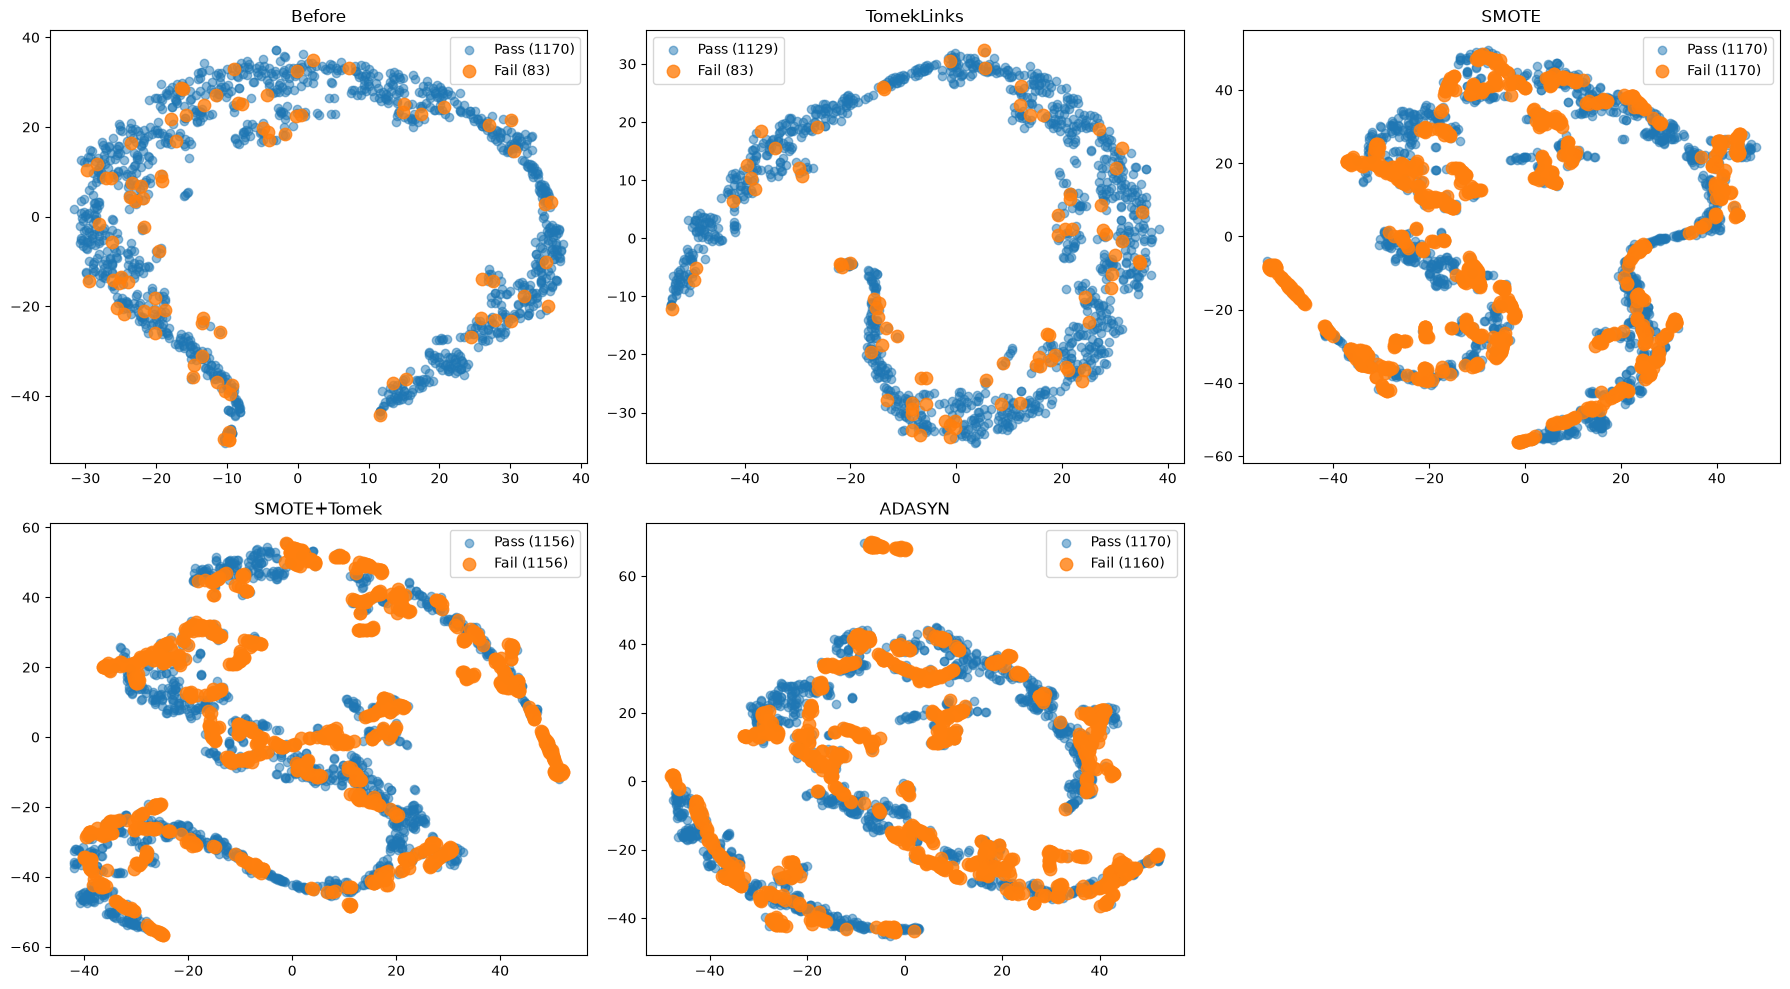

In [50]:
# 방법론별 t-SNE 비교 (Pass vs Fail)
A, B = -1, 1  # Pass, Fail

sampling_datasets = {
    "Before": (X_train, Y_train),
    "TomekLinks": (X_TomekLinks, Y_TomekLinks),
    "SMOTE": (X_SMOTE, Y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, Y_SMOTETomek),
    "ADASYN": (X_ADASYN, Y_ADASYN),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (X_s, Y_s)) in enumerate(sampling_datasets.items()):
    emb = TSNE(n_components=2, init='random', learning_rate='auto', perplexity=30, random_state=0).fit_transform(X_s)
    axes[i].scatter(emb[Y_s.values == A, 0], emb[Y_s.values == A, 1], label=f'Pass ({(Y_s==A).sum()})', alpha=0.5)
    axes[i].scatter(emb[Y_s.values == B, 0], emb[Y_s.values == B, 1], label=f'Fail ({(Y_s==B).sum()})', alpha=0.8, s=80)
    axes[i].set_title(name)
    axes[i].legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### 3-2) Sampling 전후 성능 비교

- **Before / TomekLinks**: 학습 데이터 불균형 비율을 `scale_pos_weight`로 반영
- **SMOTE / SMOTE+Tomek / ADASYN**: 이미 oversampling으로 균형을 맞췄으므로 `scale_pos_weight = 1`
- **Threshold**: 방법마다 학습 데이터에서 F1이 가장 높은 값을 찾아 적용 (공정 비교)

In [51]:
from xgboost import XGBClassifier

Y_test_xgb = Y_test.map({-1: 0, 1: 1})
OVERSAMPLED_METHODS = {"SMOTE", "SMOTE+Tomek", "ADASYN"}


def get_scale_pos_weight(name, Y_tr):
    # oversampling 후에는 class weight를 다시 크게 주면 이중 보정이 됨
    if name in OVERSAMPLED_METHODS:
        return 1.0
    neg, pos = (Y_tr == -1).sum(), (Y_tr == 1).sum()
    return neg / pos


def find_best_threshold(model, X_tr, Y_tr_xgb):
    proba = model.predict_proba(X_tr)[:, 1]
    best_t, best_f1 = 0.25, 0.0
    for t in np.arange(0.10, 0.55, 0.05):
        pred = (proba >= t).astype(int)
        f = f1_score(Y_tr_xgb, pred, pos_label=1, zero_division=0)
        if f >= best_f1:
            best_f1, best_t = f, t
    return best_t


results = []
for name, (X_tr, Y_tr) in sampling_datasets.items():
    Y_tr_xgb = Y_tr.map({-1: 0, 1: 1})
    scale_pos_weight = get_scale_pos_weight(name, Y_tr)

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=0,
        verbosity=0,
    )
    xgb.fit(X_tr, Y_tr_xgb)

    threshold = find_best_threshold(xgb, X_tr, Y_tr_xgb)
    pred = (xgb.predict_proba(X_test)[:, 1] >= threshold).astype(int)

    results.append({
        "Method": name,
        "Threshold": round(threshold, 2),
        "Precision": round(precision_score(Y_test_xgb, pred, pos_label=1, zero_division=0), 4),
        "Recall": round(recall_score(Y_test_xgb, pred, pos_label=1, zero_division=0), 4),
        "F1-score": round(f1_score(Y_test_xgb, pred, pos_label=1, zero_division=0), 4),
    })

pd.DataFrame(results)

,Method,Precision,Recall,F1-score
0,Before,0.2353,0.1905,0.2105
1,TomekLinks,0.2143,0.1429,0.1714
2,SMOTE,0.1176,0.0952,0.1053
3,SMOTE+Tomek,0.1176,0.0952,0.1053
4,ADASYN,0.1667,0.1429,0.1538


### 3-3) 하이퍼파라미터 튜닝으로 F1-score 개선

기본 설정 대비, **Resampling 방법 + XGBoost** 하이퍼파라미터를 함께 탐색해 F1-score를 끌어올릴 수 있는지 확인합니다.

- `imblearn.pipeline.Pipeline` + `StratifiedKFold`로 **학습 fold에만 resampling** 적용 (데이터 누수 방지)
- oversampling 방법은 `scale_pos_weight = 1`, Before/TomekLinks는 불균형 비율 반영
- 성능 비교 셀과 동일하게 **방법별 최적 threshold**로 최종 Test F1 계산
- 빠른 실행을 위해 **2-fold CV + 방법당 6회 무작위 탐색** (약 2~4분 소요)

In [52]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

Y_train_xgb = Y_train.map({-1: 0, 1: 1})
Y_test_xgb = Y_test.map({-1: 0, 1: 1})
OVERSAMPLED_METHODS = {"SMOTE", "SMOTE+Tomek", "ADASYN"}
ORIGINAL_SCALE = (Y_train == -1).sum() / (Y_train == 1).sum()

f1_minority = make_scorer(f1_score, pos_label=1, zero_division=0)
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
N_ITER = 6


def make_xgb(scale_pos_weight):
    return XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=0,
        verbosity=0,
    )


xgb_param_dist = {
    "clf__max_depth": [4, 6, 8],
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.05, 0.1],
}

search_configs = {
    "Before": {
        "sampler": "passthrough",
        "scale_pos_weight": ORIGINAL_SCALE,
        "param_dist": xgb_param_dist,
    },
    "TomekLinks": {
        "sampler": TomekLinks(),
        "scale_pos_weight": ORIGINAL_SCALE,
        "param_dist": {
            "sampler__sampling_strategy": ["majority", "auto"],
            **xgb_param_dist,
        },
    },
    "SMOTE": {
        "sampler": SMOTE(random_state=10),
        "scale_pos_weight": 1.0,
        "param_dist": {
            "sampler__k_neighbors": [3, 5],
            "sampler__sampling_strategy": [0.5, 1.0],
            **xgb_param_dist,
        },
    },
    "SMOTE+Tomek": {
        "sampler": SMOTETomek(random_state=10),
        "scale_pos_weight": 1.0,
        "param_dist": {
            "sampler__smote__k_neighbors": [3, 5],
            "sampler__smote__sampling_strategy": [0.5, 1.0],
            **xgb_param_dist,
        },
    },
    "ADASYN": {
        "sampler": ADASYN(random_state=10),
        "scale_pos_weight": 1.0,
        "param_dist": {
            "sampler__n_neighbors": [3, 5],
            "sampler__sampling_strategy": [0.5, 1.0],
            **xgb_param_dist,
        },
    },
}

baseline_f1 = pd.DataFrame(results).set_index("Method")["F1-score"].to_dict()
tuned_results = []

for name, cfg in search_configs.items():
    pipe = ImbPipeline([
        ("sampler", cfg["sampler"]),
        ("clf", make_xgb(cfg["scale_pos_weight"])),
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=cfg["param_dist"],
        n_iter=N_ITER,
        scoring=f1_minority,
        cv=cv,
        random_state=42,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, Y_train_xgb)

    best_model = search.best_estimator_
    if cfg["sampler"] == "passthrough":
        X_resampled, Y_resampled = X_train, Y_train_xgb
    else:
        X_resampled, Y_resampled = best_model.named_steps["sampler"].fit_resample(X_train, Y_train_xgb)

    threshold = find_best_threshold(best_model.named_steps["clf"], X_resampled, Y_resampled)
    pred = (best_model.predict_proba(X_test)[:, 1] >= threshold).astype(int)

    test_f1 = f1_score(Y_test_xgb, pred, pos_label=1, zero_division=0)
    baseline = baseline_f1.get(name)

    tuned_results.append({
        "Method": name,
        "Baseline F1": baseline,
        "CV F1 (tuned)": round(search.best_score_, 4),
        "Test F1 (tuned)": round(test_f1, 4),
        "F1 개선": round(test_f1 - baseline, 4) if baseline is not None else None,
        "Threshold": round(threshold, 2),
        "Precision": round(precision_score(Y_test_xgb, pred, pos_label=1, zero_division=0), 4),
        "Recall": round(recall_score(Y_test_xgb, pred, pos_label=1, zero_division=0), 4),
        "Best Params": search.best_params_,
    })

tuned_df = pd.DataFrame(tuned_results).sort_values("Test F1 (tuned)", ascending=False).reset_index(drop=True)

print("=== 튜닝 전후 F1-score 비교 ===")
display(tuned_df.drop(columns=["Best Params"]))

print("\n=== 방법별 최적 하이퍼파라미터 ===")
for _, row in tuned_df.iterrows():
    print(f"\n[{row['Method']}] Test F1: {row['Test F1 (tuned)']}")
    for k, v in row["Best Params"].items():
        print(f"  {k}: {v}")

best_method = tuned_df.iloc[0]["Method"]
best_f1 = tuned_df.iloc[0]["Test F1 (tuned)"]
print(f"\n최고 성능: {best_method} (Test F1 = {best_f1})")

AttributeError: 'NoneType' object has no attribute 'set_params'

---

## 4) Vibe Coding 실습

**[과제 1]**
지수는 위 t-SNE 시각화 결과(Before / TomekLinks / SMOTE / SMOTE+Tomek / ADASYN)를 보고, Resampling 기법마다 Pass와 Fail 클래스가 어떻게 다르게 분포하는지 궁금해졌습니다.

AI에게 이미지를 보여주며 각 기법의 결과가 어떤 의미를 갖는지 해석을 요청하고 원본 데이터에서 Fail 데이터가 단 83개뿐이라는 점을 함께 고려했을 때 이 문제에는 Resampling과 One-Class Learning 중 어떤 접근이 더 적합할지 AI와 논의해 보세요.